<a href="https://colab.research.google.com/github/cgm2179/Branch_2_Diffusion_Transformer_efficiency_for_small_model/blob/main/Section%207%20-%20Cameron's%20Version/regime%201%20-%20CIFAR-10%20Denoiser/CIFAR-10%20Denoiser%20-%2006_compare_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 7 — CNN regime 1 (CIFAR-10 Denoiser) · Compare Results
Loads the 5 methods' `results/*.json` from Drive (missing ones skipped). MSE + PSNR + SSIM, cost/memory, three-factor cos-sweep head-to-head, an RGB sample-reconstruction grid, and a figures+CSV export.

## 1. Setup + Load Results

In [1]:
import os, json, math, torch
import torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
device='cuda' if torch.cuda.is_available() else 'cpu'
USE_DRIVE, DRIVE_SUBDIR = True, 'Section7_r1_cifar10_denoiser'
if USE_DRIVE:
    try:
        from google.colab import drive; drive.mount('/content/drive'); STORE=os.path.join('/content/drive/MyDrive',DRIVE_SUBDIR)
    except Exception as e:
        print('Drive mount failed:',e); STORE=os.path.join('/content',DRIVE_SUBDIR)
else:
    STORE=os.path.join('.',DRIVE_SUBDIR)
RESULTS_DIR=os.path.join(STORE,'results'); CKPT_DIR=os.path.join(STORE,'checkpoints')
EXTRA_RESULTS_DIRS = []   # merge results JSONs exported from other Google accounts (see merge cell)
EXTRA_CKPT_DIRS    = []
METHODS=['backprop','two_factor','three_factor_clean','three_factor_normal','three_factor_noisy','backprop_100M']
LABELS={'backprop':'Backprop','two_factor':'Two-factor Hebbian','three_factor_clean':'Three-factor clean (cos~0.5)','three_factor_normal':'Three-factor normal (cos~0.09)','three_factor_noisy':'Three-factor noisy (cos~0.01)','backprop_100M':'Backprop 100M (ceiling)'}
COLORS={'backprop':'#1F3864','two_factor':'#B8860B','three_factor_clean':'#C62828','three_factor_normal':'#E67E22','three_factor_noisy':'#7B1FA2','backprop_100M':'#2E7D32'}
def _find(m):
    for d in [RESULTS_DIR]+EXTRA_RESULTS_DIRS:
        p=os.path.join(d,f'{m}.json')
        if os.path.exists(p): return p
    return None
R={}
for m in METHODS:
    p=_find(m)
    if p:
        R[m]=json.load(open(p)); s=R[m]['summary']; md=R[m]['meta']
        print(f'loaded {m:24} {md["total_steps"]:>9,} steps  {md["wall_clock_sec"]/3600:5.2f}h  best MSE {s["best_mse"]:.5f}  best PSNR {s["best_psnr"]:.2f}dB  best SSIM {s["best_ssim"]:.3f}')
    else:
        print(f'MISSING {m}.json (run the {m} notebook first)')

Drive mount failed: mount failed
MISSING backprop.json (run the backprop notebook first)
MISSING two_factor.json (run the two_factor notebook first)
MISSING three_factor_clean.json (run the three_factor_clean notebook first)
MISSING three_factor_normal.json (run the three_factor_normal notebook first)
MISSING three_factor_noisy.json (run the three_factor_noisy notebook first)
MISSING backprop_100M.json (run the backprop_100M notebook first)


## (optional) merge results from another account

In [2]:
# --- OPTIONAL: merge results exported from ANOTHER Google account (upload <method>.json / .pt) ---
import os
try:
    from google.colab import files
    up = files.upload(); import shutil
    for fn in up:
        dst = '/content/extra_results' if fn.endswith('.json') else '/content/extra_ckpts'
        os.makedirs(dst, exist_ok=True); shutil.move(fn, os.path.join(dst, fn))
    if os.path.isdir('/content/extra_results') and '/content/extra_results' not in EXTRA_RESULTS_DIRS:
        EXTRA_RESULTS_DIRS.append('/content/extra_results')
    if os.path.isdir('/content/extra_ckpts') and '/content/extra_ckpts' not in EXTRA_CKPT_DIRS:
        EXTRA_CKPT_DIRS.append('/content/extra_ckpts')
    print('re-run the load cell above; EXTRA_RESULTS_DIRS =', EXTRA_RESULTS_DIRS)
except Exception as e:
    print('nothing uploaded (fine if all results are on this Drive):', e)

re-run the load cell above; EXTRA_RESULTS_DIRS = []


## 2. Compare curves (MSE + PSNR + SSIM)

/tmp/ipykernel_7347/336020493.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].set_xlabel('hours'); ax[0].set_ylabel('test MSE / pixel'); ax[0].set_title('Reconstruction MSE vs time'); ax[0].legend(fontsize=8)
/tmp/ipykernel_7347/336020493.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].set_xlabel('hours'); ax[1].set_ylabel('PSNR (dB)'); ax[1].set_title('PSNR vs time'); ax[1].legend(fontsize=8)
/tmp/ipykernel_7347/336020493.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].set_xlabel('hours'); ax[2].set_ylabel('SSIM'); ax[2].set_title('SSIM vs time'); ax[2].legend(fontsize=8)


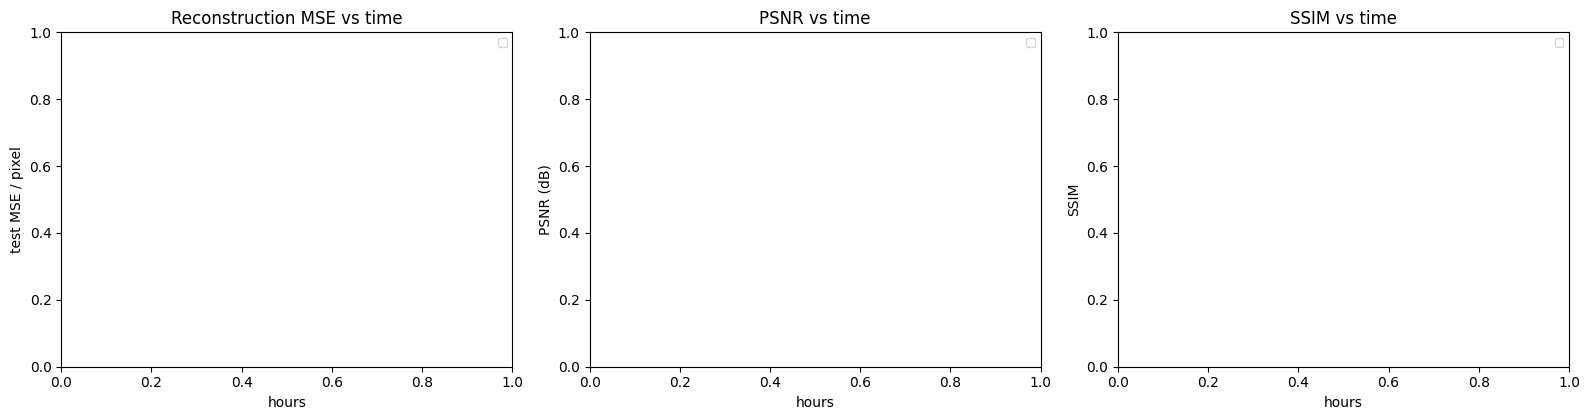

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
for m in R:
    c = R[m]['curve']; hrs = [t/3600 for t in c['t_sec']]
    ax[0].plot(hrs, c['test_mse'],  'o-', color=COLORS[m], label=LABELS[m])
    ax[1].plot(hrs, c['test_psnr'], 'o-', color=COLORS[m], label=LABELS[m])
    ax[2].plot(hrs, c['test_ssim'], 'o-', color=COLORS[m], label=LABELS[m])
ax[0].set_xlabel('hours'); ax[0].set_ylabel('test MSE / pixel'); ax[0].set_title('Reconstruction MSE vs time'); ax[0].legend(fontsize=8)
ax[1].set_xlabel('hours'); ax[1].set_ylabel('PSNR (dB)'); ax[1].set_title('PSNR vs time'); ax[1].legend(fontsize=8)
ax[2].set_xlabel('hours'); ax[2].set_ylabel('SSIM'); ax[2].set_title('SSIM vs time'); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. Cost & Memory

In [4]:
def fwd_equiv(m):
    st = R[m]['meta']['total_steps']
    if m.startswith('three_factor'): return st * 2 * R[m]['meta']['config'].get('M', 0)
    if m.startswith('backprop'): return st * 3
    return st * 2
print(f'{"method":30}{"steps":>10}{"fwd-equiv":>14}{"wall h":>8}{"peak MB":>9}')
print('-'*71)
for m in R:
    md = R[m]['meta']
    print(f'{LABELS[m]:30}{md["total_steps"]:>10,}{fwd_equiv(m):>14,}{md["wall_clock_sec"]/3600:>8.2f}{md.get("peak_mem_mb", float("nan")):>9.1f}')

method                             steps     fwd-equiv  wall h  peak MB
-----------------------------------------------------------------------


## Peak training memory — backprop vs. forward-only (no activation tape)

Measures the **activation tape** backprop must retain for its backward pass — memory the forward-only three-factor rule never allocates (it only *evaluates* the loss). Self-contained and unexecuted: run it to print the numbers next to the accuracy results. Exact (`torch.autograd.graph.saved_tensors_hooks`), at this section's training batch size.

In [5]:
# ============================================================================
# Peak training memory: backprop vs the forward-only three-factor rule.
# Backprop must retain an "activation tape" (one saved tensor per layer op) so
# the backward pass can run; the forward-only rule only EVALUATES the loss, so
# it stores none of it -> training memory stays at the inference footprint.
# Measured exactly via autograd's own saved-tensor hooks (not an estimate).
# Also writes peak_training_memory.csv into the exports/ folder so it rides
# along in the results zip next to summary.csv. Self-contained + unexecuted.
# ============================================================================
import torch, torch.nn as nn, torch.nn.functional as F
_MEM_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def _activation_tape_bytes(model, xshape, lossfn, make_target):
    model = model.to(_MEM_DEVICE)
    _pp = {p.untyped_storage().data_ptr() for p in model.parameters()}
    _seen, _isp = {}, {}
    def _pack(t):
        st = t.untyped_storage(); dp = st.data_ptr()
        _seen[dp] = st.nbytes(); _isp[dp] = (dp in _pp); return t
    def _unpack(t): return t
    x = torch.randn(*xshape, device=_MEM_DEVICE)
    with torch.autograd.graph.saved_tensors_hooks(_pack, _unpack):
        out = model(x); loss = lossfn(out, make_target(out)); loss.backward()
    return sum(nb for dp, nb in _seen.items() if not _isp[dp])  # activations only (params excluded)

def _report_training_memory(label, model, xshape, lossfn, make_target):
    P = sum(p.numel() for p in model.parameters()); pmem = P*4
    tape = _activation_tape_bytes(model, xshape, lossfn, make_target)
    common = 4*pmem; bp, loc = common + tape, common; MB = 1e6
    print("="*78)
    print(f"PEAK TRAINING MEMORY  |  {label}")
    print(f"  params P = {P:,}  ({pmem/MB:.2f} MB weights)   |   batch = {xshape[0]}   |   device = {_MEM_DEVICE}")
    print("-"*78)
    print(f"  activation tape backprop must retain : {tape/MB:8.2f} MB   ({tape/max(pmem,1):.1f}x the weights)")
    print(f"  forward-only three-factor rule       : {0.0:8.2f} MB   (no tape -- structural)")
    print(f"  est. training memory (same Adam both = 4P shared):")
    print(f"      backprop     : {bp/MB:8.2f} MB")
    print(f"      forward-only : {loc/MB:8.2f} MB   ->  backprop needs {bp/max(loc,1):.2f}x the memory")
    print(f"  (tape ~ linear in batch; measured via torch.autograd saved_tensors_hooks)")
    print("="*78)
    return {"section": label, "arch": type(model).__name__.replace("_Mem",""),
            "params": P, "batch": xshape[0], "weights_MB": round(pmem/MB, 2),
            "activation_tape_MB": round(tape/MB, 2), "tape_over_weights": round(tape/max(pmem,1), 2),
            "backprop_train_MB": round(bp/MB, 2), "forward_only_train_MB": round(loc/MB, 2),
            "backprop_over_forward_only": round(bp/max(loc,1), 2)}

class _MemConvAE(nn.Module):
    def __init__(self, conv_c=32, latent=118):
        super().__init__(); c2=2*conv_c; self._c2=c2
        self.enc=nn.Sequential(nn.Conv2d(3,conv_c,3,2,1),nn.ReLU(),nn.Conv2d(conv_c,c2,3,2,1),nn.ReLU())
        self.fc1=nn.Linear(c2*8*8, latent); self.fc2=nn.Linear(latent, c2*8*8)
        self.dec=nn.Sequential(nn.Upsample(scale_factor=2,mode='nearest'),nn.Conv2d(c2,conv_c,3,padding=1),nn.ReLU(),nn.Upsample(scale_factor=2,mode='nearest'),nn.Conv2d(conv_c,3,3,padding=1))
    def forward(self,x):
        h=self.enc(x); b=h.shape[0]; z=self.fc1(h.reshape(b,-1))
        h2=self.fc2(z).reshape(b,self._c2,8,8); return self.dec(h2)
_MEM_ROW = _report_training_memory("S7 CNN denoiser (CIFAR-10)", _MemConvAE(), (128,3,32,32), lambda o,t: F.mse_loss(o,t), lambda o: torch.rand_like(o))

# --- stash + persist so the export cell's zip picks it up (rides next to summary.csv) ---
PEAK_MEM_ROWS = [_MEM_ROW]
try:
    import os as _os, csv as _csv
    if 'STORE' in globals():
        _ed = _os.path.join(STORE, 'exports'); _os.makedirs(_ed, exist_ok=True)
        with open(_os.path.join(_ed, 'peak_training_memory.csv'), 'w', newline='') as _f:
            _w = _csv.DictWriter(_f, fieldnames=list(PEAK_MEM_ROWS[0].keys())); _w.writeheader()
            for _r in PEAK_MEM_ROWS: _w.writerow(_r)
        print('  saved ->', _os.path.join(_ed, 'peak_training_memory.csv'))
    else:
        print('  (STORE not defined yet -- CSV will be written by the export cell / re-run after Setup)')
except Exception as _e:
    print('  (peak_training_memory.csv not written:', _e, ')')


PEAK TRAINING MEMORY  |  S7 CNN denoiser (CIFAR-10)
  params P = 1,009,593  (4.04 MB weights)   |   batch = 128   |   device = cuda
------------------------------------------------------------------------------
  activation tape backprop must retain :    40.43 MB   (10.0x the weights)
  forward-only three-factor rule       :     0.00 MB   (no tape -- structural)
  est. training memory (same Adam both = 4P shared):
      backprop     :    56.58 MB
      forward-only :    16.15 MB   ->  backprop needs 3.50x the memory
  (tape ~ linear in batch; measured via torch.autograd saved_tensors_hooks)
  saved -> /content/Section7_r1_cifar10_denoiser/exports/peak_training_memory.csv


## 4. Head-to-head — three-factor cos sweep

In [6]:
tf = [m for m in ['three_factor_clean','three_factor_normal','three_factor_noisy'] if m in R]
if len(tf) >= 2:
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
    for m in tf:
        c = R[m]['curve']; hrs=[t/3600 for t in c['t_sec']]
        ax[0].plot(hrs, c['test_mse'],  'o-', color=COLORS[m], label=LABELS[m])
        ax[1].plot(hrs, c['test_psnr'], 'o-', color=COLORS[m], label=LABELS[m])
        ax[2].plot(c['step'], c['test_mse'], 'o-', color=COLORS[m], label=LABELS[m])
    ax[0].set_xlabel('hours'); ax[0].set_ylabel('test MSE'); ax[0].set_title('cos sweep — MSE vs time'); ax[0].legend()
    ax[1].set_xlabel('hours'); ax[1].set_ylabel('PSNR (dB)'); ax[1].set_title('PSNR vs time'); ax[1].legend()
    ax[2].set_xscale('symlog'); ax[2].set_xlabel('steps'); ax[2].set_ylabel('test MSE'); ax[2].set_title('MSE vs steps'); ax[2].legend()
    plt.tight_layout(); plt.show()
    print(f'{"variant":30}{"M":>10}{"cos~":>8}{"steps":>10}{"best_mse":>11}{"best_psnr":>11}{"best_ssim":>11}')
    print('-'*91)
    for m in tf:
        md, s = R[m]['meta'], R[m]['summary']; M = md['config'].get('M') or 0; P = md['P']
        cos = (M/(M+P+1))**0.5 if M else float('nan')
        print(f'{LABELS[m]:30}{M:>10,}{cos:>8.3f}{md["total_steps"]:>10,}{s["best_mse"]:>11.5f}{s["best_psnr"]:>11.2f}{s["best_ssim"]:>11.3f}')
    best = min(tf, key=lambda m: R[m]['summary']['best_mse'])
    print(f'\nLowest best MSE in the budget: {LABELS[best]}.')
else:
    print('Head-to-head needs >=2 three-factor variants (03/04/05).')

Head-to-head needs >=2 three-factor variants (03/04/05).


## 5. Sample reconstructions (best model)

In [7]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvAE(nn.Module):
    """Conv encoder -> dense latent bottleneck -> Upsample+Conv decoder -> 3x32x32 logits.
    No BatchNorm (vmap-clean); Upsample+Conv instead of ConvTranspose (vmap-safe)."""
    def __init__(self, conv_c=32, latent=118):
        super().__init__()
        c2 = 2 * conv_c
        self.enc = nn.Sequential(
            nn.Conv2d(3, conv_c, 3, stride=2, padding=1), nn.ReLU(),   # 32 -> 16
            nn.Conv2d(conv_c, c2, 3, stride=2, padding=1), nn.ReLU(),  # 16 -> 8
        )
        self._c2 = c2
        self.fc1 = nn.Linear(c2 * 8 * 8, latent)
        self.fc2 = nn.Linear(latent, c2 * 8 * 8)
        self.dec = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),               # 8 -> 16
            nn.Conv2d(c2, conv_c, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),               # 16 -> 32
            nn.Conv2d(conv_c, 3, 3, padding=1),
        )
    def forward(self, x):
        h = self.enc(x)
        b = h.shape[0]
        z = self.fc1(h.reshape(b, -1))
        h2 = self.fc2(z).reshape(b, self._c2, 8, 8)
        return self.dec(h2)                                            # (B,3,32,32) logits

# sample reconstructions for the best model (highest PSNR): input | target | reconstruction (RGB)
import torch, torchvision
def _ckpt(m):
    for d in [CKPT_DIR] + EXTRA_CKPT_DIRS:
        p = os.path.join(d, f'{m}.pt')
        if os.path.exists(p): return p
    return None
_avail = [m for m in R if _ckpt(m)]
if _avail:
    best = max(_avail, key=lambda m: R[m]['summary']['best_psnr'])
    cfg = R[best]['meta']['config']
    net = ConvAE(cfg['CONV_C'], cfg['LATENT']).to(device)
    ck = torch.load(_ckpt(best), map_location=device)['method']
    net.load_state_dict(ck['net'] if 'net' in ck else ck['params']); net.eval()
    _te = torchvision.datasets.CIFAR10(globals().get('CIFAR_ROOT','./data'), train=False, download=globals().get('CIFAR_DOWNLOAD', True))
    x = (torch.as_tensor(_te.data[:8], dtype=torch.float32)/255.0).permute(0,3,1,2).to(device)
    torch.manual_seed(cfg['SEED']); xin = x + cfg['CORRUPT_SIGMA']*torch.randn_like(x) if cfg['CORRUPT_SIGMA']>0 else x
    with torch.no_grad(): rec = torch.sigmoid(net(xin)).clamp(0,1)
    def _show(ax, img): ax.imshow(img.permute(1,2,0).cpu().clamp(0,1).numpy()); ax.axis('off')
    fig, ax = plt.subplots(3, 8, figsize=(12, 4.8))
    for j in range(8):
        _show(ax[0,j], xin[j].clamp(0,1)); _show(ax[1,j], x[j]); _show(ax[2,j], rec[j])
    ax[0,0].text(-0.3,0.5,'input',rotation=90,va='center',ha='center',transform=ax[0,0].transAxes)
    ax[1,0].text(-0.3,0.5,'target',rotation=90,va='center',ha='center',transform=ax[1,0].transAxes)
    ax[2,0].text(-0.3,0.5,'reconstruction',rotation=90,va='center',ha='center',transform=ax[2,0].transAxes)
    plt.suptitle(f'Best model: {LABELS[best]} (PSNR {R[best]["summary"]["best_psnr"]:.2f}dB, SSIM {R[best]["summary"]["best_ssim"]:.3f})')
    plt.tight_layout(); plt.show()
else:
    print('no checkpoints available (run the method notebooks first)')

no checkpoints available (run the method notebooks first)


## 6. Summary table

In [8]:
print(f'{"Experiment":30}{"Steps":>10}{"Init MSE":>11}{"Best MSE":>11}{"Best PSNR":>11}{"Best SSIM":>11}')
print('-'*84)
for m in R:
    md, s = R[m]['meta'], R[m]['summary']
    print(f'{LABELS[m]:30}{md["total_steps"]:>10,}{s["initial_mse"]:>11.5f}{s["best_mse"]:>11.5f}{s["best_psnr"]:>11.2f}{s["best_ssim"]:>11.3f}')

Experiment                         Steps   Init MSE   Best MSE  Best PSNR  Best SSIM
------------------------------------------------------------------------------------


In [9]:
# ── Per-method denoising results + full metrics (paste right BEFORE the export cell) ──
# Rebuilds every method that has a checkpoint, denoises the SAME test images with each, prints a
# side-by-side MSE / PSNR / SSIM table, and draws one grid: noisy-input row, target row, one row per method.
import os, math, csv, torch, torchvision, numpy as np
import torch.nn as nn, torch.nn.functional as F

class ConvAE(nn.Module):
    def __init__(self, conv_c=32, latent=118):
        super().__init__(); c2 = 2*conv_c
        self.enc = nn.Sequential(nn.Conv2d(3, conv_c, 3, 2, 1), nn.ReLU(),
                                 nn.Conv2d(conv_c, c2, 3, 2, 1), nn.ReLU())
        self._c2 = c2; self.fc1 = nn.Linear(c2*8*8, latent); self.fc2 = nn.Linear(latent, c2*8*8)
        self.dec = nn.Sequential(nn.Upsample(scale_factor=2, mode='nearest'),
                                 nn.Conv2d(c2, conv_c, 3, padding=1), nn.ReLU(),
                                 nn.Upsample(scale_factor=2, mode='nearest'),
                                 nn.Conv2d(conv_c, 3, 3, padding=1))
    def forward(self, x):
        h = self.enc(x); b = h.shape[0]
        z = self.fc1(h.reshape(b, -1)); h2 = self.fc2(z).reshape(b, self._c2, 8, 8)
        return self.dec(h2)

def _gwin(ch, ks=7, s=1.5):
    c = torch.arange(ks, dtype=torch.float32) - (ks-1)/2
    g = torch.exp(-(c**2)/(2*s*s)); g = g/g.sum()
    return (g[:, None]*g[None, :]).expand(ch, 1, ks, ks).contiguous()
@torch.no_grad()
def ssim(a, b):
    w = _gwin(a.shape[1]).to(a.device); C1, C2 = 0.01**2, 0.03**2; ch = a.shape[1]; p = w.shape[-1]//2
    ma = F.conv2d(a, w, padding=p, groups=ch); mb = F.conv2d(b, w, padding=p, groups=ch)
    va = F.conv2d(a*a, w, padding=p, groups=ch) - ma*ma
    vb = F.conv2d(b*b, w, padding=p, groups=ch) - mb*mb
    vab = F.conv2d(a*b, w, padding=p, groups=ch) - ma*mb
    return (((2*ma*mb+C1)*(2*vab+C2))/((ma*ma+mb*mb+C1)*(va+vb+C2))).mean().item()

_CR = globals().get('CIFAR_ROOT', './data'); _DL = globals().get('CIFAR_DOWNLOAD', True)
_te = torchvision.datasets.CIFAR10(_CR, train=False, download=_DL)
N_EVAL, N_SHOW = 1000, 8
Xtgt = (torch.as_tensor(_te.data, dtype=torch.float32)/255.0).permute(0, 3, 1, 2)[:N_EVAL].to(device)

def _ckpt(m):
    for d in [CKPT_DIR] + list(globals().get('EXTRA_CKPT_DIRS', [])):
        p = os.path.join(d, f'{m}.pt')
        if os.path.exists(p): return p
    return None

rows, recons, noisy_disp = [], {}, None
for m in [k for k in METHODS if k in R]:
    cp = _ckpt(m)
    if cp is None:
        print(f'skip {m:24} (no checkpoint on this Drive)'); continue
    cfg = R[m]['meta']['config']
    net = ConvAE(cfg['CONV_C'], cfg['LATENT']).to(device)
    ck = torch.load(cp, map_location=device)['method']
    net.load_state_dict(ck['net'] if 'net' in ck else ck['params']); net.eval()
    sig = cfg.get('CORRUPT_SIGMA', 0.0)
    torch.manual_seed(cfg.get('SEED', 0))
    Xin = Xtgt + sig*torch.randn_like(Xtgt) if sig > 0 else Xtgt   # noisy input for a denoiser (sig=0 -> clean)
    with torch.no_grad():
        rec = torch.sigmoid(net(Xin)).clamp(0, 1)
        mse = F.mse_loss(rec, Xtgt).item()
    rows.append([m, R[m]['meta']['P'], round(mse, 5), round(10*math.log10(1/max(mse,1e-12)), 2), round(ssim(rec, Xtgt), 4)])
    recons[m] = rec[:N_SHOW].cpu()
    noisy_disp = Xin[:N_SHOW].clamp(0, 1).cpu()                    # same seed+sigma across methods -> one shared view

# --- metrics table ---
if rows:
    print(f'{"method":30}{"P":>12}{"MSE":>10}{"PSNR(dB)":>11}{"SSIM":>9}')
    print('-'*72)
    for r in rows: print(f'{LABELS[r[0]]:30}{r[1]:>12,}{r[2]:>10.5f}{r[3]:>11.2f}{r[4]:>9.4f}')
    best = max(rows, key=lambda r: r[3])[0]
    print(f'\nBest denoising (highest PSNR): {LABELS[best]}')
else:
    print('No checkpoints available yet — run the method notebooks (or merge checkpoints) first.')

_EXPORT = os.path.join(STORE, 'exports'); os.makedirs(_EXPORT, exist_ok=True)
if rows:
    with open(os.path.join(_EXPORT, 'per_method_metrics.csv'), 'w', newline='') as f:
        w = csv.writer(f); w.writerow(['method','P','mse','psnr_db','ssim']); [w.writerow(r) for r in rows]

# --- grid: noisy input | target | one row per method ---
if recons:
    order = [m for m in METHODS if m in recons]
    grid = [('noisy input', noisy_disp), ('target', Xtgt[:N_SHOW].cpu())] + [(LABELS[m].split(' (')[0], recons[m], m) for m in order]
    nrow = len(grid)
    fig, ax = plt.subplots(nrow, N_SHOW, figsize=(1.5*N_SHOW, 1.5*nrow))
    if nrow == 1: ax = ax[None, :]
    for r, row in enumerate(grid):
        name, imgs = row[0], row[1]; col = row[2] if len(row) > 2 else None
        for j in range(N_SHOW):
            ax[r, j].imshow(imgs[j].permute(1,2,0).clamp(0,1).numpy()); ax[r, j].axis('off')
        ax[r, 0].text(-0.35, 0.5, name, fontsize=(9 if col is None else 7), rotation=90, va='center', ha='center',
                      transform=ax[r,0].transAxes, fontweight=('bold' if col is None else 'normal'),
                      color=(COLORS[col] if col else 'black'))
    plt.suptitle('Per-method denoising (noisy input · target · each method)'); plt.tight_layout()
    fig.savefig(os.path.join(_EXPORT, 'denoising_by_method.png'), dpi=130, bbox_inches='tight'); plt.show()

# --- PSNR + SSIM bar chart per method ---
if rows:
    ms = [r[0] for r in rows]; xs = np.arange(len(ms))
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(1.7*len(ms)+4, 4))
    a1.bar(xs, [r[3] for r in rows], color=[COLORS[m] for m in ms])
    a1.set_xticks(xs); a1.set_xticklabels([LABELS[m].split(' (')[0] for m in ms], rotation=30, ha='right', fontsize=8)
    a1.set_ylabel('PSNR (dB)'); a1.set_title('PSNR by method')
    a2.bar(xs, [r[4] for r in rows], color=[COLORS[m] for m in ms])
    a2.set_xticks(xs); a2.set_xticklabels([LABELS[m].split(' (')[0] for m in ms], rotation=30, ha='right', fontsize=8)
    a2.set_ylabel('SSIM'); a2.set_ylim(0, 1); a2.set_title('SSIM by method')
    plt.tight_layout(); fig.savefig(os.path.join(_EXPORT, 'psnr_ssim_by_method.png'), dpi=130, bbox_inches='tight'); plt.show()

100%|██████████| 170M/170M [21:29<00:00, 132kB/s]


No checkpoints available yet — run the method notebooks (or merge checkpoints) first.


## 7. Export figures + CSV → Drive

In [10]:
# Export every figure (PNG) + data (CSV) -> a Drive folder, then download a zip.
import os, csv, glob, shutil
EXPORT_DIR = os.path.join(STORE, 'exports'); os.makedirs(EXPORT_DIR, exist_ok=True)
if R:
    ckeys = []
    for m in R:
        for k in R[m]['curve']:
            if k not in ckeys: ckeys.append(k)
    with open(os.path.join(EXPORT_DIR, 'curves.csv'), 'w', newline='') as f:
        w = csv.writer(f); w.writerow(['method'] + ckeys)
        for m in R:
            c = R[m]['curve']; n = len(c.get('t_sec', []))
            for i in range(n): w.writerow([m] + [c[k][i] if (k in c and i < len(c[k])) else '' for k in ckeys])
    skeys = []
    for m in R:
        for k in R[m]['summary']:
            if k not in skeys: skeys.append(k)
    with open(os.path.join(EXPORT_DIR, 'summary.csv'), 'w', newline='') as f:
        w = csv.writer(f); w.writerow(['method','P','total_steps','wall_clock_h','M','cos'] + skeys)
        for m in R:
            md, s = R[m]['meta'], R[m]['summary']; M = md['config'].get('M') or 0
            cos = round((M/(M+md['P']+1))**0.5, 4) if M else ''
            w.writerow([m, md['P'], md['total_steps'], round(md['wall_clock_sec']/3600,3), M, cos] + [s.get(k,'') for k in skeys])
    print('wrote curves.csv, summary.csv')
def _save(fig, name): fig.savefig(os.path.join(EXPORT_DIR, name), dpi=130, bbox_inches='tight'); plt.close(fig)
if R:
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
    for m in R:
        c = R[m]['curve']; hrs=[t/3600 for t in c['t_sec']]
        ax[0].plot(hrs, c['test_mse'],'o-',color=COLORS[m],label=LABELS[m])
        ax[1].plot(hrs, c['test_psnr'],'o-',color=COLORS[m],label=LABELS[m])
        ax[2].plot(hrs, c['test_ssim'],'o-',color=COLORS[m],label=LABELS[m])
    ax[0].set_ylabel('test MSE'); ax[1].set_ylabel('PSNR (dB)'); ax[2].set_ylabel('SSIM')
    for a in ax: a.set_xlabel('hours'); a.legend(fontsize=8)
    _save(fig, 'curves_mse_psnr_ssim.png'); print('wrote comparison figure')
for d in {RESULTS_DIR, CKPT_DIR, STORE}:
    for png in glob.glob(os.path.join(d, '*.png')):
        try: shutil.copy(png, EXPORT_DIR)
        except Exception: pass
print('\nexport folder:', EXPORT_DIR); print(' ', sorted(os.listdir(EXPORT_DIR)))
_zt = '/content' if os.path.isdir('/content') else os.path.dirname(EXPORT_DIR)
zip_path = shutil.make_archive(os.path.join(_zt, DRIVE_SUBDIR + '_exports'), 'zip', EXPORT_DIR)
try:
    if os.path.abspath(os.path.dirname(zip_path)) != os.path.abspath(STORE): shutil.copy(zip_path, STORE)
except Exception as e: print('(could not copy zip to Drive):', e)
print('zip:', zip_path)
try:
    from google.colab import files; files.download(zip_path)
except Exception as e:
    print('(download only runs in Colab):', e)


export folder: /content/Section7_r1_cifar10_denoiser/exports
  ['peak_training_memory.csv']
zip: /content/Section7_r1_cifar10_denoiser_exports.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>